## Phase 1 - Data Prep

In [ ]:
import pandas as pd
import numpy as np

def load_data(url):
    # Column names as defined by UCI dataset documentation
    column_names = [
        'id',
        'clump_thickness',
        'cell_size_uniformity',
        'cell_shape_uniformity',
        'marginal_adhesion',
        'single_ep_cell_size',
        'bare_nuclei',
        'bland_chromatin',
        'normal_nucleoli',
        'mitoses',
        'class'
    ]

    # Load the CSV — no header exists in the file so header=None
    df = pd.read_csv(url, header=None, names=column_names)

    # Drop the ID column — it carries no useful information
    df = df.drop(columns=['id'])

    return df


#Run it
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
df = load_data(url)

# Quick sanity check
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)

Shape: (699, 10)

First 5 rows:
   clump_thickness  cell_size_uniformity  cell_shape_uniformity  \
0                5                     1                      1   
1                5                     4                      4   
2                3                     1                      1   
3                6                     8                      8   
4                4                     1                      1   

   marginal_adhesion  single_ep_cell_size bare_nuclei  bland_chromatin  \
0                  1                    2           1                3   
1                  5                    7          10                3   
2                  1                    2           2                3   
3                  1                    3           4                3   
4                  3                    2           1                3   

   normal_nucleoli  mitoses  class  
0                1        1      2  
1                2        1      2  
2        

In [2]:
def handle_missing_values(df):
    # Step 1 — Replace '?' strings with NaN so pandas can recognize them
    df['bare_nuclei'] = df['bare_nuclei'].replace('?', np.nan)

    # Step 2 — Convert column to numeric (was string/object)
    df['bare_nuclei'] = pd.to_numeric(df['bare_nuclei'])

    # Step 3 — Report how many are missing before filling
    missing_count = df['bare_nuclei'].isna().sum()
    print(f"Missing values in 'bare_nuclei': {missing_count}")

    # Step 4 — Fill missing values with the median of the column
    median_val = df['bare_nuclei'].median()
    print(f"Filling with median value: {median_val}")
    df['bare_nuclei'] = df['bare_nuclei'].fillna(median_val)

    # Step 5 — Convert back to int to match other columns
    df['bare_nuclei'] = df['bare_nuclei'].astype(int)

    # Step 6 — Final check: any missing values left anywhere?
    print(f"\nTotal missing values in entire dataset: {df.isna().sum().sum()}")

    return df


#  Run it
df = handle_missing_values(df)

# Confirm the fix
print("\nData types after fix:")
print(df.dtypes)

Missing values in 'bare_nuclei': 16
Filling with median value: 1.0

Total missing values in entire dataset: 0

Data types after fix:
clump_thickness          int64
cell_size_uniformity     int64
cell_shape_uniformity    int64
marginal_adhesion        int64
single_ep_cell_size      int64
bare_nuclei              int64
bland_chromatin          int64
normal_nucleoli          int64
mitoses                  int64
class                    int64
dtype: object


In [3]:
def normalize_features(df):
    # Separate features from the label
    # We never touch the class column during normalization
    feature_cols = [col for col in df.columns if col != 'class']

    # Extract features and labels as separate numpy arrays
    X = df[feature_cols].values.astype(float)  # shape: (699, 9)
    y = df['class'].values                      # shape: (699,)

    # Min-Max normalization — done manually (no sklearn!)
    X_min = X.min(axis=0)   # minimum per feature column
    X_max = X.max(axis=0)   # maximum per feature column

    X_normalized = (X - X_min) / (X_max - X_min)

    print("Normalization complete!")
    print(f"Feature matrix shape : {X_normalized.shape}")
    print(f"Labels shape         : {y.shape}")
    print(f"\nBefore normalization (first row): {X[0]}")
    print(f"After  normalization (first row): {X_normalized[0].round(4)}")
    print(f"\nMin per feature: {X_normalized.min(axis=0)}")
    print(f"Max per feature: {X_normalized.max(axis=0)}")

    return X_normalized, y


# Run it
X, y = normalize_features(df)

Normalization complete!
Feature matrix shape : (699, 9)
Labels shape         : (699,)

Before normalization (first row): [5. 1. 1. 1. 2. 1. 3. 1. 1.]
After  normalization (first row): [0.4444 0.     0.     0.     0.1111 0.     0.2222 0.     0.    ]

Min per feature: [0. 0. 0. 0. 0. 0. 0. 0. 0.]
Max per feature: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Phase 2 — K-Means

## How it works
1. Pick K random points from the data as starting centroids
2. Assign every point to the nearest centroid using Euclidean distance
3. Recalculate each centroid as the mean of all points in its cluster
4. Repeat steps 2-3 until the centroids stop moving (convergence)

## How we picked K

We used the Elbow Method , we ran K-Means for K = 1 to 10 and plotted the WCSS for each K. The WCSS dropped
sharply from K=1 to K=2 and then slowed down, so K=2 was the clear choice.
This also makes sense because the dataset has exactly two classes: Benign and Malignant.

In [4]:
def initialize_centroids(X, k):
    
    # Randomly pick k data points from X as starting centroids.
    # We use a fixed random seed so results are reproducible.
   
    np.random.seed(42)

    # Randomly choose k indices from the dataset (no replacement)
    indices = np.random.choice(X.shape[0], size=k, replace=False)

    # Return those rows as our initial centroids
    centroids = X[indices]

    print(f"Initialized {k} centroids from random data points")
    print(f"Centroids shape: {centroids.shape}")

    return centroids


# Run it
centroids = initialize_centroids(X, k=2)
print(f"\nFirst centroid : {centroids[0].round(4)}")
print(f"Second centroid: {centroids[1].round(4)}")

Initialized 2 centroids from random data points
Centroids shape: (2, 9)

First centroid : [0.     0.     0.1111 0.     0.2222 0.     0.     0.     0.    ]
Second centroid: [0.3333 0.     0.     0.     0.1111 0.     0.1111 0.     0.    ]


In [5]:
def assign_clusters(X, centroids):
    
    distances = []
    
    for centroid in centroids:
        # calculate euclidean distance from every point to this centroid
        diff = X - centroid
        dist = np.sqrt((diff ** 2).sum(axis=1))
        distances.append(dist)
    
    # distances is now shape (k, 699), we transpose to get (699, k)
    distances = np.array(distances).T
    
    # assign each point to the closest centroid
    labels = np.argmin(distances, axis=1)
    
    return labels


# run it
labels = assign_clusters(X, centroids)

print("Labels shape:", labels.shape)
print("Unique clusters:", np.unique(labels))
print("Points in cluster 0:", (labels == 0).sum())
print("Points in cluster 1:", (labels == 1).sum())
print("First 20 labels:", labels[:20])

Labels shape: (699,)
Unique clusters: [0 1]
Points in cluster 0: 210
Points in cluster 1: 489
First 20 labels: [1 1 1 1 1 1 0 0 0 1 0 0 1 0 1 1 1 1 1 1]


In [9]:

def update_centroids(X, labels, k):
    
    new_centroids = []
    
    for i in range(k):
        cluster_points = X[labels == i]
        
        # if a cluster is empty, reinitialize to a random point
        if len(cluster_points) == 0:
            random_idx = np.random.randint(0, X.shape[0])
            new_centroids.append(X[random_idx])
        else:
            new_centroids.append(cluster_points.mean(axis=0))
    
    return np.array(new_centroids)
# run it
new_centroids = update_centroids(X, labels, k=2)

print("New centroids shape:", new_centroids.shape)
print("\nCentroid 0:", new_centroids[0].round(4))
print("Centroid 1:", new_centroids[1].round(4))

# see how much the centroids moved from initialization
print("\nHow much centroids moved:")
print("Centroid 0 shift:", np.round(np.abs(new_centroids[0] - centroids[0]), 4))
print("Centroid 1 shift:", np.round(np.abs(new_centroids[1] - centroids[1]), 4))

New centroids shape: (2, 9)

Centroid 0: [0.227  0.0335 0.0492 0.0375 0.1209 0.033  0.1226 0.028  0.0122]
Centroid 1: [0.6833 0.642  0.6349 0.5252 0.4953 0.7597 0.5655 0.5641 0.1714]

How much centroids moved:
Centroid 0 shift: [0. 0. 0. 0. 0. 0. 0. 0. 0.]
Centroid 1 shift: [0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [10]:
def kmeans(X, k, max_iters=100, tol=1e-4):
    
    # step 1 - initialize centroids
    centroids = initialize_centroids(X, k)
    
    for i in range(max_iters):
        
        # step 2 - assign clusters
        labels = assign_clusters(X, centroids)
        
        # step 3 - update centroids
        new_centroids = update_centroids(X, labels, k)
        
        # step 4 - check convergence
        shift = np.abs(new_centroids - centroids).sum()
        
        print(f"Iteration {i+1} | centroid shift: {shift:.6f}")
        
        if shift < tol:
            print(f"\nConverged at iteration {i+1}!")
            break
            
        centroids = new_centroids
    
    return centroids, labels


# run it
centroids, labels = kmeans(X, k=2)

print("\nFinal cluster sizes:")
for i in range(2):
    print(f"  Cluster {i}: {(labels == i).sum()} points")

Initialized 2 centroids from random data points
Centroids shape: (2, 9)
Iteration 1 | centroid shift: 2.781981
Iteration 2 | centroid shift: 2.840861
Iteration 3 | centroid shift: 0.370358
Iteration 4 | centroid shift: 0.029592
Iteration 5 | centroid shift: 0.014429
Iteration 6 | centroid shift: 0.000000

Converged at iteration 6!

Final cluster sizes:
  Cluster 0: 465 points
  Cluster 1: 234 points


Initialized 1 centroids from random data points
Centroids shape: (1, 9)
Iteration 1 | centroid shift: 1.795899
Iteration 2 | centroid shift: 0.000000

Converged at iteration 2!
K=1 | WCSS: 607.1612
Initialized 2 centroids from random data points
Centroids shape: (2, 9)
Iteration 1 | centroid shift: 2.781981
Iteration 2 | centroid shift: 2.840861
Iteration 3 | centroid shift: 0.370358
Iteration 4 | centroid shift: 0.029592
Iteration 5 | centroid shift: 0.014429
Iteration 6 | centroid shift: 0.000000

Converged at iteration 6!
K=2 | WCSS: 243.4369
Initialized 3 centroids from random data points
Centroids shape: (3, 9)
Iteration 1 | centroid shift: 4.632453
Iteration 2 | centroid shift: 3.142753
Iteration 3 | centroid shift: 0.688331
Iteration 4 | centroid shift: 0.635907
Iteration 5 | centroid shift: 0.455454
Iteration 6 | centroid shift: 0.335328
Iteration 7 | centroid shift: 0.156115
Iteration 8 | centroid shift: 0.044732
Iteration 9 | centroid shift: 0.107770
Iteration 10 | centroid s

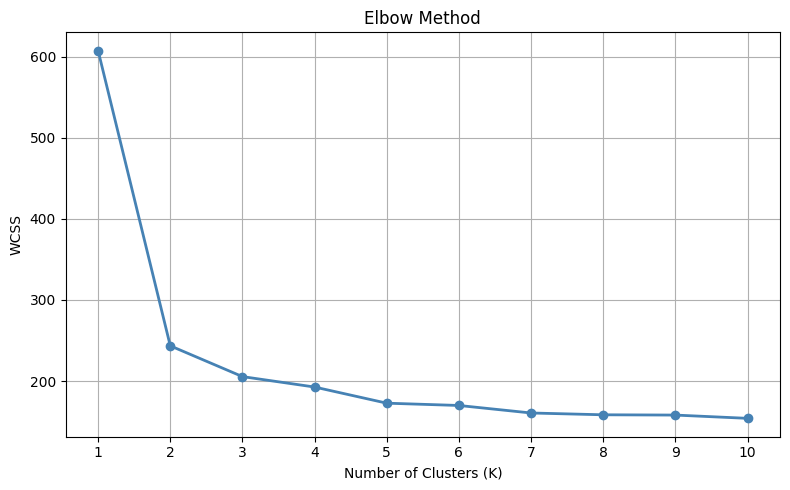

In [11]:
import matplotlib.pyplot as plt

def compute_wcss(X, labels, centroids):
    
    wcss = 0
    for i, centroid in enumerate(centroids):
        cluster_points = X[labels == i]
        wcss += ((cluster_points - centroid) ** 2).sum()
    
    return wcss


def elbow_method(X, max_k=10):
    
    wcss_scores = []
    
    for k in range(1, max_k + 1):
        centroids, labels = kmeans(X, k)
        wcss = compute_wcss(X, labels, centroids)
        wcss_scores.append(wcss)
        print(f"K={k} | WCSS: {wcss:.4f}")
    
    # plot the elbow curve
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_k + 1), wcss_scores, marker='o', color='steelblue', linewidth=2)
    plt.title('Elbow Method')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('WCSS')
    plt.xticks(range(1, max_k + 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return wcss_scores


# run it
wcss_scores = elbow_method(X)

In [12]:
def evaluate_kmeans(labels, y):
    
    # convert real labels from (2,4) to (0,1)
    # 2 = benign = 0, 4 = malignant = 1
    y_binary = (y == 4).astype(int)
    
    # try both mappings and pick the better one
    # mapping A: cluster 0 = benign, cluster 1 = malignant
    acc_A = (labels == y_binary).sum() / len(y)
    
    # mapping B: cluster 0 = malignant, cluster 1 = benign (flipped)
    acc_B = (1 - labels == y_binary).sum() / len(y)
    
    if acc_A >= acc_B:
        accuracy = acc_A
        final_labels = labels
    else:
        accuracy = acc_B
        final_labels = 1 - labels  # flip the labels
    
    print(f"K-Means Accuracy: {accuracy * 100:.2f}%")
    
    # build confusion matrix manually
    TP = ((final_labels == 1) & (y_binary == 1)).sum()  # malignant correctly found
    TN = ((final_labels == 0) & (y_binary == 0)).sum()  # benign correctly found
    FP = ((final_labels == 1) & (y_binary == 0)).sum()  # benign wrongly called malignant
    FN = ((final_labels == 0) & (y_binary == 1)).sum()  # malignant wrongly called benign
    
    print("\nConfusion Matrix:")
    print(f"                 Predicted Benign    Predicted Malignant")
    print(f"Actual Benign         {TN}                  {FP}")
    print(f"Actual Malignant      {FN}                  {TP}")
    
    return accuracy, final_labels


# run it
centroids, labels = kmeans(X, k=2)
accuracy, final_labels = evaluate_kmeans(labels, y)

Initialized 2 centroids from random data points
Centroids shape: (2, 9)
Iteration 1 | centroid shift: 2.781981
Iteration 2 | centroid shift: 2.840861
Iteration 3 | centroid shift: 0.370358
Iteration 4 | centroid shift: 0.029592
Iteration 5 | centroid shift: 0.014429
Iteration 6 | centroid shift: 0.000000

Converged at iteration 6!
K-Means Accuracy: 95.85%

Confusion Matrix:
                 Predicted Benign    Predicted Malignant
Actual Benign         447                  11
Actual Malignant      18                  223


## Phase 3 - GMM

In [13]:
def initialize_gmm(X, k, kmeans_centroids):
    
    n_samples, n_features = X.shape
    
    # means come directly from k-means — this is the key link!
    means = kmeans_centroids.copy()
    
    # covariances start as identity matrices (one per cluster)
    covariances = []
    for i in range(k):
        cov = np.eye(n_features) * 0.1
        covariances.append(cov)
    covariances = np.array(covariances)
    
    # weights start equal — each cluster gets same importance
    weights = np.ones(k) / k
    
    print(f"GMM initialized with K={k}")
    print(f"Means shape      : {means.shape}")
    print(f"Covariances shape: {covariances.shape}")
    print(f"Weights          : {weights}")
    print(f"\nInitial means (from K-Means):")
    for i in range(k):
        print(f"  Cluster {i}: {means[i].round(4)}")
    
    return means, covariances, weights


# run it — we pass the centroids we got from kmeans()
means, covariances, weights = initialize_gmm(X, k=2, kmeans_centroids=centroids)

GMM initialized with K=2
Means shape      : (2, 9)
Covariances shape: (2, 9, 9)
Weights          : [0.5 0.5]

Initial means (from K-Means):
  Cluster 0: [0.227  0.0335 0.0492 0.0375 0.1209 0.033  0.1226 0.028  0.0122]
  Cluster 1: [0.6833 0.642  0.6349 0.5252 0.4953 0.7597 0.5655 0.5641 0.1714]


In [14]:
def gaussian_pdf(X, mean, cov):
    
    n_samples, n_features = X.shape
    
    # add small value to diagonal to prevent singular matrix issues
    cov = cov + np.eye(n_features) * 1e-10
    
    # compute determinant and inverse of covariance matrix
    det = np.linalg.det(cov)
    inv = np.linalg.inv(cov)
    
    # normalization constant out front
    norm_const = 1.0 / (((2 * np.pi) ** (n_features / 2)) * (np.sqrt(det)))
    
    # compute exponent for all points at once
    diff = X - mean  # shape (n_samples, n_features)
    
    # (x-mu)^T * Sigma^-1 * (x-mu) for each point
    exponent = -0.5 * np.sum(diff @ inv * diff, axis=1)
    
    probs = norm_const * np.exp(exponent)
    
    return probs  # shape (n_samples,)


# run it — test on cluster 0
probs = gaussian_pdf(X, means[0], covariances[0])

print(f"Probabilities shape: {probs.shape}")
print(f"First 5 probabilities: {probs[:5]}")
print(f"Min prob: {probs.min():.6f}")
print(f"Max prob: {probs.max():.6f}")
print(f"Any NaN? {np.isnan(probs).any()}")

Probabilities shape: (699,)
First 5 probabilities: [5.86980791e+00 2.29660871e-03 7.25017746e+00 1.54585219e-03
 5.96643780e+00]
Min prob: 0.000000
Max prob: 7.807619
Any NaN? False


In [15]:
def e_step(X, means, covariances, weights, k):
    
    n_samples = X.shape[0]
    
    # store probability of each point under each gaussian
    responsibilities = np.zeros((n_samples, k))
    
    for i in range(k):
        # weight * probability for each cluster
        responsibilities[:, i] = weights[i] * gaussian_pdf(X, means[i], covariances[i])
    
    # normalize across clusters so each row sums to 1
    row_sums = responsibilities.sum(axis=1, keepdims=True)
    
    # avoid division by zero
    row_sums = np.where(row_sums == 0, 1e-10, row_sums)
    
    responsibilities = responsibilities / row_sums
    
    return responsibilities  # shape (n_samples, k)


# run it
responsibilities = e_step(X, means, covariances, weights, k=2)

print(f"Responsibilities shape: {responsibilities.shape}")
print(f"\nFirst 5 rows (each row should sum to 1):")
print(responsibilities[:5].round(4))
print(f"\nRow sums (should all be 1.0):")
print(responsibilities[:5].sum(axis=1).round(4))
print(f"\nAny NaN? {np.isnan(responsibilities).any()}")

Responsibilities shape: (699, 2)

First 5 rows (each row should sum to 1):
[[1.     0.    ]
 [0.0088 0.9912]
 [1.     0.    ]
 [0.0079 0.9921]
 [1.     0.    ]]

Row sums (should all be 1.0):
[1. 1. 1. 1. 1.]

Any NaN? False


In [16]:
def m_step(X, responsibilities, k):
    
    n_samples, n_features = X.shape
    
    new_means = []
    new_covariances = []
    new_weights = []
    
    for i in range(k):
        
        # responsibilities for cluster i, shape (n_samples,)
        r = responsibilities[:, i]
        
        # sum of responsibilities for this cluster
        r_sum = r.sum()
        
        # update weight
        new_weight = r_sum / n_samples
        
        # update mean — weighted average of all points
        new_mean = (r[:, np.newaxis] * X).sum(axis=0) / r_sum
        
        # update covariance — weighted outer product
        diff = X - new_mean
        new_cov = (r[:, np.newaxis] * diff).T @ diff / r_sum
        
        # add small regularization to keep matrix invertible
        new_cov += np.eye(n_features) * 1e-6
        
        new_means.append(new_mean)
        new_covariances.append(new_cov)
        new_weights.append(new_weight)
    
    return np.array(new_means), np.array(new_covariances), np.array(new_weights)


# run it
new_means, new_covariances, new_weights = m_step(X, responsibilities, k=2)

print(f"Updated weights    : {new_weights.round(4)}")
print(f"\nUpdated mean 0: {new_means[0].round(4)}")
print(f"Updated mean 1: {new_means[1].round(4)}")
print(f"\nCovariance 0 shape: {new_covariances[0].shape}")
print(f"Covariance 0 diagonal: {np.diag(new_covariances[0]).round(4)}")

Updated weights    : [0.668 0.332]

Updated mean 0: [0.2275 0.0344 0.0496 0.038  0.1223 0.038  0.1242 0.0294 0.0114]
Updated mean 1: [0.6861 0.6452 0.639  0.5283 0.4955 0.7556 0.566  0.5655 0.1742]

Covariance 0 shape: (9, 9)
Covariance 0 diagonal: [0.0408 0.0068 0.0107 0.011  0.0092 0.0143 0.0146 0.0106 0.0061]


In [17]:
def compute_log_likelihood(X, means, covariances, weights, k):
    
    n_samples = X.shape[0]
    likelihood = np.zeros(n_samples)
    
    for i in range(k):
        likelihood += weights[i] * gaussian_pdf(X, means[i], covariances[i])
    
    # avoid log(0)
    likelihood = np.where(likelihood == 0, 1e-10, likelihood)
    
    return np.sum(np.log(likelihood))


def gmm(X, k, kmeans_centroids, max_iters=100, tol=1e-4):
    
    # step 1 - initialize using k-means results
    means, covariances, weights = initialize_gmm(X, k, kmeans_centroids)
    
    prev_log_likelihood = None
    
    for i in range(max_iters):
        
        # step 2 - e-step
        responsibilities = e_step(X, means, covariances, weights, k)
        
        # step 3 - m-step
        means, covariances, weights = m_step(X, responsibilities, k)
        
        # step 4 - check convergence via log-likelihood
        log_likelihood = compute_log_likelihood(X, means, covariances, weights, k)
        
        print(f"Iteration {i+1} | log-likelihood: {log_likelihood:.4f}")
        
        if prev_log_likelihood is not None:
            if abs(log_likelihood - prev_log_likelihood) < tol:
                print(f"\nConverged at iteration {i+1}!")
                break
        
        prev_log_likelihood = log_likelihood
    
    return means, covariances, weights, responsibilities


# run it
gmm_means, gmm_covs, gmm_weights, gmm_resp = gmm(X, k=2, kmeans_centroids=centroids)

print(f"\nFinal weights: {gmm_weights.round(4)}")
print(f"Final mean 0 : {gmm_means[0].round(4)}")
print(f"Final mean 1 : {gmm_means[1].round(4)}")

GMM initialized with K=2
Means shape      : (2, 9)
Covariances shape: (2, 9, 9)
Weights          : [0.5 0.5]

Initial means (from K-Means):
  Cluster 0: [0.227  0.0335 0.0492 0.0375 0.1209 0.033  0.1226 0.028  0.0122]
  Cluster 1: [0.6833 0.642  0.6349 0.5252 0.4953 0.7597 0.5655 0.5641 0.1714]
Iteration 1 | log-likelihood: 3534.0372
Iteration 2 | log-likelihood: 4377.7732
Iteration 3 | log-likelihood: 4831.2924
Iteration 4 | log-likelihood: 5918.0739
Iteration 5 | log-likelihood: 5977.2466
Iteration 6 | log-likelihood: 6013.8398
Iteration 7 | log-likelihood: 6076.9838
Iteration 8 | log-likelihood: 6103.9694
Iteration 9 | log-likelihood: 6135.3119
Iteration 10 | log-likelihood: 6357.1764
Iteration 11 | log-likelihood: 7183.6968
Iteration 12 | log-likelihood: 7184.8576
Iteration 13 | log-likelihood: 7185.2623
Iteration 14 | log-likelihood: 7185.3392
Iteration 15 | log-likelihood: 7185.3438
Iteration 16 | log-likelihood: 7185.3439
Iteration 17 | log-likelihood: 7185.3439

Converged at it

In [20]:
def evaluate_gmm(responsibilities, y):
    
    # convert soft responsibilities to hard labels
    labels = np.argmax(responsibilities, axis=1)
    
    # convert real labels from (2,4) to (0,1)
    y_binary = (y == 4).astype(int)
    
    # try both mappings
    acc_A = (labels == y_binary).sum() / len(y)
    acc_B = ((1 - labels) == y_binary).sum() / len(y)
    
    if acc_A >= acc_B:
        accuracy = acc_A
        final_labels = labels
    else:
        accuracy = acc_B
        final_labels = 1 - labels
    
    print(f"GMM Accuracy: {accuracy * 100:.2f}%")
    
    # confusion matrix
    TP = ((final_labels == 1) & (y_binary == 1)).sum()
    TN = ((final_labels == 0) & (y_binary == 0)).sum()
    FP = ((final_labels == 1) & (y_binary == 0)).sum()
    FN = ((final_labels == 0) & (y_binary == 1)).sum()
    
    print("\nConfusion Matrix:")
    print(f"                 Predicted Benign    Predicted Malignant")
    print(f"Actual Benign         {TN}                  {FP}")
    print(f"Actual Malignant      {FN}                  {TP}")
    
    return accuracy, final_labels


# run it
gmm_accuracy, gmm_final_labels = evaluate_gmm(gmm_resp, y)

# compare k-means vs gmm side by side
print("\n****** Final Comparison ******")
print(f"K-Means Accuracy : {accuracy * 100:.2f}%")
print(f"GMM Accuracy     : {gmm_accuracy * 100:.2f}%")

if gmm_accuracy > accuracy:
    print("\nGMM outperformed K-Means! ")
elif gmm_accuracy == accuracy:
    print("\nBoth models performed equally!")
else:
    print("\nK-Means outperformed GMM ")

GMM Accuracy: 87.12%

Confusion Matrix:
                 Predicted Benign    Predicted Malignant
Actual Benign         368                  90
Actual Malignant      0                  241

****** Final Comparison ******
K-Means Accuracy : 95.85%
GMM Accuracy     : 87.12%

K-Means outperformed GMM 
